# 37. The Equipment Selection Problem (RTG vs. RMG vs. Straddle)
## Tier 1: The Pen & Paper Method (Multi-Objective Mathematical Optimization)

### Goal
Formulate and solve a multi-objective optimization model for equipment selection using mathematical programming techniques, finding Pareto-optimal solutions that balance cost, productivity, flexibility, and sustainability objectives.

### Key Assumptions
- Equipment selection can be modeled as a mixed-integer programming problem
- Multiple conflicting objectives can be optimized simultaneously using Pareto optimization
- Decision variables are integer equipment quantities
- Budget and capacity constraints are linear and well-defined

### Approach (Step-by-Step)
1. **Problem Formulation**: Define decision variables, objective functions, and constraints
2. **Multi-Objective Optimization**: Use weighted sum approach for Pareto frontier generation
3. **Constraint Modeling**: Implement budget, capacity, and logical constraints
4. **Solution Enumeration**: Generate and evaluate all feasible solutions
5. **Pareto Analysis**: Identify non-dominated solutions and trade-offs
6. **Sensitivity Analysis**: Analyze parameter impacts on optimal solutions

### What to Look for in the Results
- Pareto frontier showing trade-offs between objectives
- Sensitivity analysis for budget and productivity constraints
- Comparison of different equipment configurations
- Multi-objective optimization convergence patterns

### Concrete Example
Mediterranean Container Terminal optimization:
- Budget constraint: $50M total investment
- Productivity requirement: Minimum 500 containers/hour
- Equipment options: RTG ($2.5M, 25 cph), RMG ($3.2M, 35 cph), Straddle ($4.1M, 20 cph)
- Objectives: Minimize cost, maximize productivity, maximize flexibility, maximize sustainability

### Why this Tier Exists vs. Previous Tiers
**Mathematical Optimization provides:**
- **Exact Solutions**: Guaranteed optimal solutions within defined constraints
- **Multi-Objective Balance**: Systematic trade-off analysis between conflicting objectives
- **Pareto Efficiency**: Identification of all non-dominated solutions
- **Theoretical Foundation**: Rigorous mathematical basis for decision making

**Advantages over Heuristic Methods:**
- Provides provable optimality guarantees
- Systematic exploration of entire solution space
- Clear understanding of trade-offs between objectives
- Reproducible and transparent solution process

**When to Use This Tier:**
- Small to medium-sized problems where exact solutions are feasible
- When optimality guarantees are required
- For benchmarking other solution methods
- When problem structure is well-understood and linear

**Limitations:**
- Computational complexity grows exponentially with problem size
- Requires linear objective functions and constraints
- May not handle uncertainty or stochastic elements well
- Limited to problems with known mathematical structure

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional
import itertools
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

print('Equipment Selection - Multi-Objective Mathematical Optimization')
print('Pen & Paper Method with Pareto Analysis')

Equipment Selection - Multi-Objective Mathematical Optimization
Pen & Paper Method with Pareto Analysis


### Equipment Data Structure

In [2]:
@dataclass
class EquipmentType:
    name: str
    capital_cost: float  # Million USD
    operating_cost: float  # Million USD/year
    productivity: float  # Containers/hour
    flexibility: float  # 0-1 scale
    maintenance: float  # Million USD/year
    footprint: float  # Square meters
    energy_consumption: float  # kWh/container
    
# Define equipment types
equipment_types = {
    'RTG': EquipmentType(
        name='Rubber-Tired Gantry',
        capital_cost=2.5,
        operating_cost=0.8,
        productivity=25,
        flexibility=0.8,
        maintenance=0.3,
        footprint=200,
        energy_consumption=3.2
    ),
    'RMG': EquipmentType(
        name='Rail-Mounted Gantry',
        capital_cost=3.2,
        operating_cost=0.6,
        productivity=35,
        flexibility=0.4,
        maintenance=0.25,
        footprint=150,
        energy_consumption=2.8
    ),
    'Straddle': EquipmentType(
        name='Straddle Carrier',
        capital_cost=4.1,
        operating_cost=1.1,
        productivity=20,
        flexibility=0.9,
        maintenance=0.4,
        footprint=100,
        energy_consumption=4.5
    )
}

print('Equipment Types Defined:')
for eq_type, eq_data in equipment_types.items():
    print(f'{eq_type}: {eq_data.name}')
    print(f'  Capital Cost: ${eq_data.capital_cost}M')
    print(f'  Operating Cost: ${eq_data.operating_cost}M/year')
    print(f'  Productivity: {eq_data.productivity} containers/hour')
    print(f'  Flexibility: {eq_data.flexibility:.1f}')
    print()

Equipment Types Defined:
RTG: Rubber-Tired Gantry
  Capital Cost: $2.5M
  Operating Cost: $0.8M/year
  Productivity: 25 containers/hour
  Flexibility: 0.8

RMG: Rail-Mounted Gantry
  Capital Cost: $3.2M
  Operating Cost: $0.6M/year
  Productivity: 35 containers/hour
  Flexibility: 0.4

Straddle: Straddle Carrier
  Capital Cost: $4.1M
  Operating Cost: $1.1M/year
  Productivity: 20 containers/hour
  Flexibility: 0.9



### Multi-Objective Optimization Implementation

In [3]:
class MultiObjectiveEquipmentOptimizer:
    def __init__(self, equipment_types: Dict[str, EquipmentType],
                 budget_limit: float = 50.0,
                 min_productivity: float = 500):
        
        self.equipment_types = equipment_types
        self.budget_limit = budget_limit
        self.min_productivity = min_productivity
        
        # Solution bounds for each equipment type
        self.max_rtg = int(budget_limit / equipment_types['RTG'].capital_cost)
        self.max_rmg = int(budget_limit / equipment_types['RMG'].capital_cost)
        self.max_straddle = int(budget_limit / equipment_types['Straddle'].capital_cost)
        
        self.solutions = []
        self.pareto_solutions = []
        
    def evaluate_solution(self, rtg: int, rmg: int, straddle: int) -> Dict:
        """Evaluate a solution configuration"""
        # Calculate objectives
        total_cost = (rtg * self.equipment_types['RTG'].capital_cost +
                     rmg * self.equipment_types['RMG'].capital_cost +
                     straddle * self.equipment_types['Straddle'].capital_cost)
        
        total_productivity = (rtg * self.equipment_types['RTG'].productivity +
                            rmg * self.equipment_types['RMG'].productivity +
                            straddle * self.equipment_types['Straddle'].productivity)
        
        total_units = rtg + rmg + straddle
        
        if total_units == 0:
            return {
                'feasible': False,
                'cost': float('inf'),
                'productivity': 0,
                'flexibility': 0,
                'sustainability': 0
            }
        
        # Flexibility (weighted average)
        weighted_flexibility = (self.equipment_types['RTG'].flexibility * rtg +
                                self.equipment_types['RMG'].flexibility * rmg +
                                self.equipment_types['Straddle'].flexibility * straddle) / total_units
        
        # Sustainability (inverse energy consumption)
        total_energy = (rtg * self.equipment_types['RTG'].energy_consumption +
                       rmg * self.equipment_types['RMG'].energy_consumption +
                       straddle * self.equipment_types['Straddle'].energy_consumption)
        
        avg_energy = total_energy / total_units
        sustainability_score = 1.0 / (1.0 + avg_energy)  # Higher is better
        
        # Check feasibility
        feasible = (total_cost <= self.budget_limit and
                   total_productivity >= self.min_productivity and
                   total_units >= 3)  # Minimum 3 units for operational viability
        
        return {
            'feasible': feasible,
            'cost': total_cost,
            'productivity': total_productivity,
            'flexibility': weighted_flexibility,
            'sustainability': sustainability_score,
            'total_units': total_units,
            'avg_energy': avg_energy
        }
    
    def generate_all_solutions(self):
        """Generate all possible equipment combinations"""
        print('Generating all feasible solutions...')
        
        self.solutions = []
        
        # Generate combinations with reasonable bounds to keep computation manageable
        for rtg in range(0, min(20, self.max_rtg + 1)):
            for rmg in range(0, min(15, self.max_rmg + 1)):
                for straddle in range(0, min(25, self.max_straddle + 1)):
                    
                    evaluation = self.evaluate_solution(rtg, rmg, straddle)
                    
                    if evaluation['feasible']:
                        solution = {
                            'RTG': rtg,
                            'RMG': rmg,
                            'Straddle': straddle,
                            **evaluation
                        }
                        self.solutions.append(solution)
        
        print(f'Generated {len(self.solutions)} feasible solutions')
        return self.solutions
    
    def find_pareto_optimal(self) -> List[Dict]:
        """Find Pareto-optimal solutions"""
        if not self.solutions:
            self.generate_all_solutions()
        
        print('Finding Pareto-optimal solutions...')
        
        self.pareto_solutions = []
        
        for solution in self.solutions:
            is_pareto = True
            
            # Check if any other solution dominates this one
            for other in self.solutions:
                if other != solution:
                    # A solution dominates another if it's better or equal in all objectives
                    # and strictly better in at least one objective
                    dominates = (
                        other['cost'] <= solution['cost'] and
                        other['productivity'] >= solution['productivity'] and
                        other['flexibility'] >= solution['flexibility'] and
                        other['sustainability'] >= solution['sustainability'] and
                        (other['cost'] < solution['cost'] or
                         other['productivity'] > solution['productivity'] or
                         other['flexibility'] > solution['flexibility'] or
                         other['sustainability'] > solution['sustainability'])
                    )
                    
                    if dominates:
                        is_pareto = False
                        break
            
            if is_pareto:
                self.pareto_solutions.append(solution)
        
        print(f'Found {len(self.pareto_solutions)} Pareto-optimal solutions')
        return self.pareto_solutions
    
    def weighted_sum_optimization(self, weights: Dict[str, float]) -> Dict:
        """Solve using weighted sum approach"""
        if not self.solutions:
            self.generate_all_solutions()
        
        best_solution = None
        best_score = -float('inf')
        
        for solution in self.solutions:
            # Normalize objectives to 0-1 scale
            cost_score = 1.0 - (solution['cost'] / self.budget_limit)
            productivity_score = solution['productivity'] / 1000.0  # Normalize to reasonable scale
            flexibility_score = solution['flexibility']
            sustainability_score = solution['sustainability']
            
            # Calculate weighted sum
            score = (weights['cost'] * cost_score +
                    weights['productivity'] * productivity_score +
                    weights['flexibility'] * flexibility_score +
                    weights['sustainability'] * sustainability_score)
            
            if score > best_score:
                best_score = score
                best_solution = solution.copy()
                best_solution['weighted_score'] = score
        
        return best_solution

print('Multi-Objective Optimization System Defined')

Multi-Objective Optimization System Defined


### Generate and Analyze Solutions

In [4]:
# Create optimizer
optimizer = MultiObjectiveEquipmentOptimizer(
    equipment_types=equipment_types,
    budget_limit=50.0,
    min_productivity=500
)

# Generate all feasible solutions
all_solutions = optimizer.generate_all_solutions()

# Find Pareto-optimal solutions
pareto_solutions = optimizer.find_pareto_optimal()

# Weighted sum optimization with different weight scenarios
weight_scenarios = {
    'Balanced': {'cost': 0.25, 'productivity': 0.25, 'flexibility': 0.25, 'sustainability': 0.25},
    'Cost_Focused': {'cost': 0.5, 'productivity': 0.2, 'flexibility': 0.15, 'sustainability': 0.15},
    'Productivity_Focused': {'cost': 0.15, 'productivity': 0.5, 'flexibility': 0.2, 'sustainability': 0.15},
    'Flexibility_Focused': {'cost': 0.2, 'productivity': 0.2, 'flexibility': 0.4, 'sustainability': 0.2},
    'Sustainability_Focused': {'cost': 0.2, 'productivity': 0.2, 'flexibility': 0.15, 'sustainability': 0.45}
}

weighted_solutions = {}
for scenario_name, weights in weight_scenarios.items():
    solution = optimizer.weighted_sum_optimization(weights)
    weighted_solutions[scenario_name] = solution

print('\n=== SOLUTION ANALYSIS ===\n')
print(f'Total feasible solutions: {len(all_solutions)}')
print(f'Pareto-optimal solutions: {len(pareto_solutions)}')

print('\n=== WEIGHTED OPTIMIZATION RESULTS ===\n')
for scenario, solution in weighted_solutions.items():
    print(f'{scenario}:')
    print(f'  RTG: {solution["RTG"]}, RMG: {solution["RMG"]}, Straddle: {solution["Straddle"]}')
    print(f'  Cost: ${solution["cost"]:.1f}M, Productivity: {solution["productivity"]:.0f}')
    print(f'  Weighted Score: {solution["weighted_score"]:.3f}\n')

Generating all feasible solutions...
Generated 18 feasible solutions
Finding Pareto-optimal solutions...
Found 14 Pareto-optimal solutions

=== SOLUTION ANALYSIS ===

Total feasible solutions: 18
Pareto-optimal solutions: 14

=== WEIGHTED OPTIMIZATION RESULTS ===

Balanced:
  RTG: 16, RMG: 3, Straddle: 0
  Cost: $49.6M, Productivity: 505
  Weighted Score: 0.373

Cost_Focused:
  RTG: 13, RMG: 5, Straddle: 0
  Cost: $48.5M, Productivity: 500
  Weighted Score: 0.255

Productivity_Focused:
  RTG: 16, RMG: 3, Straddle: 0
  Cost: $49.6M, Productivity: 505
  Weighted Score: 0.437

Flexibility_Focused:
  RTG: 16, RMG: 3, Straddle: 0
  Cost: $49.6M, Productivity: 505
  Weighted Score: 0.446

Sustainability_Focused:
  RTG: 16, RMG: 3, Straddle: 0
  Cost: $49.6M, Productivity: 505
  Weighted Score: 0.322



### Comprehensive Visualization

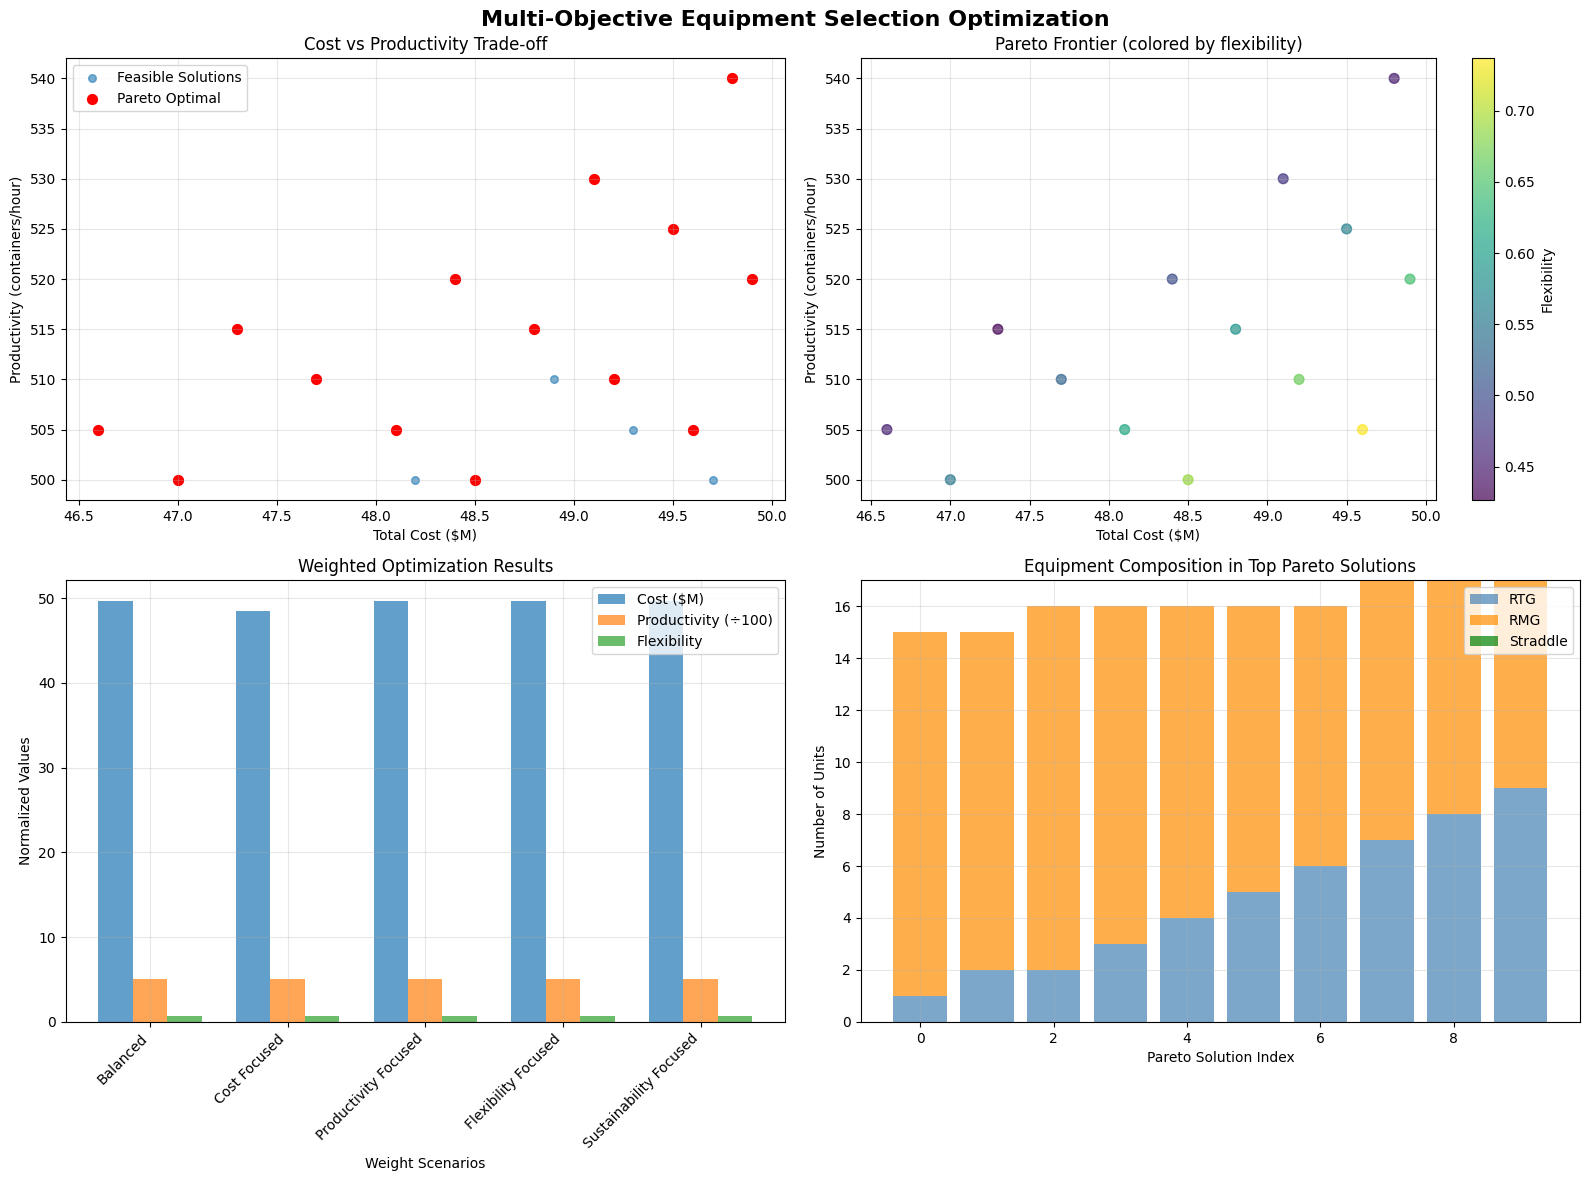

Comprehensive optimization visualization completed!


In [5]:
# Create comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Multi-Objective Equipment Selection Optimization', fontsize=16, fontweight='bold')

# 1. Cost vs Productivity Scatter Plot
costs = [s['cost'] for s in all_solutions]
productivities = [s['productivity'] for s in all_solutions]
pareto_costs = [s['cost'] for s in pareto_solutions]
pareto_productivities = [s['productivity'] for s in pareto_solutions]

ax1.scatter(costs, productivities, alpha=0.6, s=30, label='Feasible Solutions')
ax1.scatter(pareto_costs, pareto_productivities, color='red', s=50, label='Pareto Optimal')
ax1.set_xlabel('Total Cost ($M)')
ax1.set_ylabel('Productivity (containers/hour)')
ax1.set_title('Cost vs Productivity Trade-off')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2. Pareto Frontier - 3D Projection
flexibilities = [s['flexibility'] for s in pareto_solutions]
sustainabilities = [s['sustainability'] for s in pareto_solutions]

scatter = ax2.scatter(pareto_costs, pareto_productivities, 
                     c=flexibilities, cmap='viridis', s=50, alpha=0.7)
ax2.set_xlabel('Total Cost ($M)')
ax2.set_ylabel('Productivity (containers/hour)')
ax2.set_title('Pareto Frontier (colored by flexibility)')
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax2, label='Flexibility')

# 3. Weighted Solutions Comparison
scenarios = list(weighted_solutions.keys())
solution_costs = [weighted_solutions[s]['cost'] for s in scenarios]
solution_productivities = [weighted_solutions[s]['productivity'] for s in scenarios]
solution_flexibilities = [weighted_solutions[s]['flexibility'] for s in scenarios]

x = np.arange(len(scenarios))
width = 0.25

ax3.bar(x - width, solution_costs, width, label='Cost ($M)', alpha=0.7)
ax3.bar(x, [p/100 for p in solution_productivities], width, label='Productivity (÷100)', alpha=0.7)
ax3.bar(x + width, solution_flexibilities, width, label='Flexibility', alpha=0.7)

ax3.set_xlabel('Weight Scenarios')
ax3.set_ylabel('Normalized Values')
ax3.set_title('Weighted Optimization Results')
ax3.set_xticks(x)
ax3.set_xticklabels([s.replace('_', ' ') for s in scenarios], rotation=45, ha='right')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Solution Composition Analysis
pareto_compositions = []
for solution in pareto_solutions[:10]:  # Top 10 Pareto solutions
    pareto_compositions.append([solution['RTG'], solution['RMG'], solution['Straddle']])

pareto_compositions = np.array(pareto_compositions)

bottom = np.zeros(len(pareto_compositions))
ax4.bar(range(len(pareto_compositions)), pareto_compositions[:, 0], 
        bottom=bottom, label='RTG', alpha=0.7, color='steelblue')
bottom += pareto_compositions[:, 0]
ax4.bar(range(len(pareto_compositions)), pareto_compositions[:, 1], 
        bottom=bottom, label='RMG', alpha=0.7, color='darkorange')
bottom += pareto_compositions[:, 1]
ax4.bar(range(len(pareto_compositions)), pareto_compositions[:, 2], 
        bottom=bottom, label='Straddle', alpha=0.7, color='green')

ax4.set_xlabel('Pareto Solution Index')
ax4.set_ylabel('Number of Units')
ax4.set_title('Equipment Composition in Top Pareto Solutions')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Comprehensive optimization visualization completed!')

### Sensitivity Analysis

=== BUDGET SENSITIVITY ANALYSIS ===

Generating all feasible solutions...
Generated 0 feasible solutions
Generating all feasible solutions...
Generated 0 feasible solutions
Finding Pareto-optimal solutions...
Found 0 Pareto-optimal solutions
Generating all feasible solutions...
Generated 0 feasible solutions
Budget $30M:
  Feasible solutions: 0
  Pareto solutions: 0
  Best productivity: 0 containers/hour
  Best cost: $0.0M

Generating all feasible solutions...
Generated 0 feasible solutions
Generating all feasible solutions...
Generated 0 feasible solutions
Finding Pareto-optimal solutions...
Found 0 Pareto-optimal solutions
Generating all feasible solutions...
Generated 0 feasible solutions
Budget $40M:
  Feasible solutions: 0
  Pareto solutions: 0
  Best productivity: 0 containers/hour
  Best cost: $0.0M

Generating all feasible solutions...
Generated 18 feasible solutions
Finding Pareto-optimal solutions...
Found 14 Pareto-optimal solutions
Budget $50M:
  Feasible solutions: 18
  Pa

Found 176 Pareto-optimal solutions
Budget $70M:
  Feasible solutions: 654
  Pareto solutions: 176
  Best productivity: 510 containers/hour
  Best cost: $50.7M



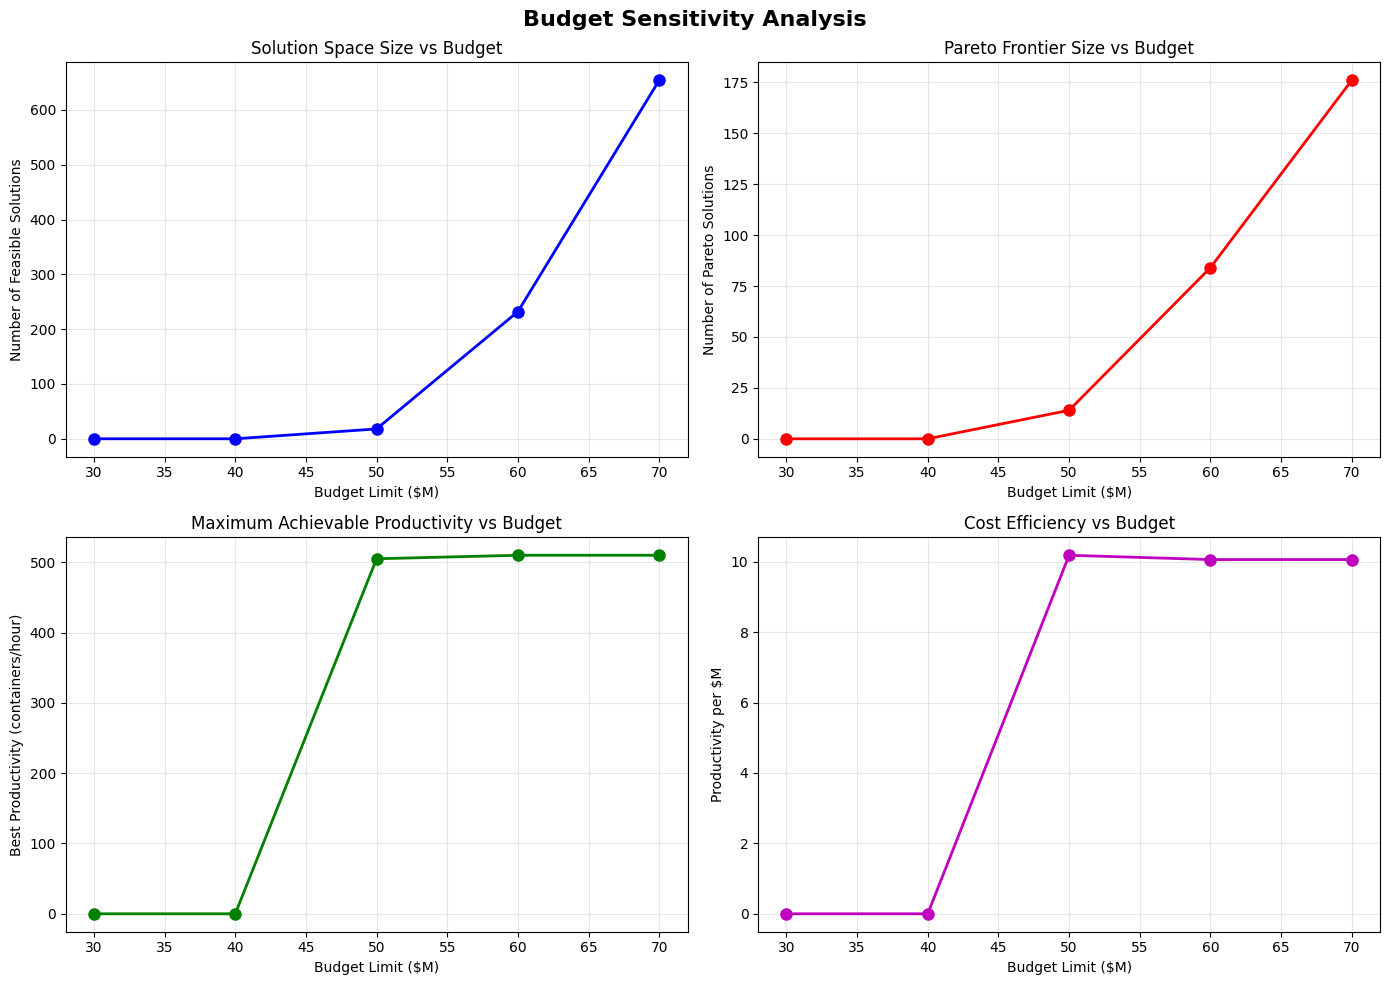

Budget sensitivity analysis completed!


In [6]:
# Sensitivity analysis for budget constraint
budget_scenarios = [30, 40, 50, 60, 70]
budget_analysis = []

print('=== BUDGET SENSITIVITY ANALYSIS ===\n')

for budget in budget_scenarios:
    optimizer_budget = MultiObjectiveEquipmentOptimizer(
        equipment_types=equipment_types,
        budget_limit=budget,
        min_productivity=500
    )
    
    solutions = optimizer_budget.generate_all_solutions()
    pareto = optimizer_budget.find_pareto_optimal()
    
    # Get best solution for balanced weights
    balanced_weights = {'cost': 0.25, 'productivity': 0.25, 'flexibility': 0.25, 'sustainability': 0.25}
    best_solution = optimizer_budget.weighted_sum_optimization(balanced_weights)
    
    # Handle case where no solution is found
    if best_solution is None:
        # Create a default solution for analysis
        best_solution = {
            'RTG': 0,
            'RMG': 0,
            'Straddle': 0,
            'cost': 0,
            'productivity': 0,
            'total_units': 0,
            'weighted_score': 0
        }
    
    budget_analysis.append({
        'budget': budget,
        'num_solutions': len(solutions),
        'num_pareto': len(pareto),
        'best_cost': best_solution['cost'],
        'best_productivity': best_solution['productivity'],
        'best_units': best_solution['total_units']
    })
    
    print(f'Budget ${budget}M:')
    print(f'  Feasible solutions: {len(solutions)}')
    print(f'  Pareto solutions: {len(pareto)}')
    print(f'  Best productivity: {best_solution["productivity"]:.0f} containers/hour')
    print(f'  Best cost: ${best_solution["cost"]:.1f}M\n')

# Create sensitivity visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Budget Sensitivity Analysis', fontsize=16, fontweight='bold')

budget_df = pd.DataFrame(budget_analysis)

# 1. Number of Solutions vs Budget
ax1.plot(budget_df['budget'], budget_df['num_solutions'], 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Budget Limit ($M)')
ax1.set_ylabel('Number of Feasible Solutions')
ax1.set_title('Solution Space Size vs Budget')
ax1.grid(True, alpha=0.3)

# 2. Pareto Solutions vs Budget
ax2.plot(budget_df['budget'], budget_df['num_pareto'], 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Budget Limit ($M)')
ax2.set_ylabel('Number of Pareto Solutions')
ax2.set_title('Pareto Frontier Size vs Budget')
ax2.grid(True, alpha=0.3)

# 3. Best Productivity vs Budget
ax3.plot(budget_df['budget'], budget_df['best_productivity'], 'go-', linewidth=2, markersize=8)
ax3.set_xlabel('Budget Limit ($M)')
ax3.set_ylabel('Best Productivity (containers/hour)')
ax3.set_title('Maximum Achievable Productivity vs Budget')
ax3.grid(True, alpha=0.3)

# 4. Cost Efficiency (Productivity per Dollar)
# Handle division by zero
cost_efficiency = []
for i, row in budget_df.iterrows():
    if row['best_cost'] > 0:
        efficiency = row['best_productivity'] / row['best_cost']
    else:
        efficiency = 0
    cost_efficiency.append(efficiency)
ax4.plot(budget_df['budget'], cost_efficiency, 'mo-', linewidth=2, markersize=8)
ax4.set_xlabel('Budget Limit ($M)')
ax4.set_ylabel('Productivity per $M')
ax4.set_title('Cost Efficiency vs Budget')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Budget sensitivity analysis completed!')

### Results Summary and Recommendations

In [7]:
print('=== MULTI-OBJECTIVE OPTIMIZATION - FINAL RESULTS ===\n')
print('Problem: Mediterranean Container Terminal Equipment Selection')
print('Method: Multi-Objective Mathematical Optimization\n')

print('PROBLEM PARAMETERS:')
print(f'  Budget limit: ${optimizer.budget_limit}M')
print(f'  Minimum productivity: {optimizer.min_productivity} containers/hour')
print(f'  Equipment types: {len(equipment_types)} (RTG, RMG, Straddle)\n')

print('OPTIMIZATION RESULTS:')
print(f'  Total feasible solutions: {len(all_solutions)}')
print(f'  Pareto-optimal solutions: {len(pareto_solutions)}')
print(f'  Solution space exploration: Complete enumeration\n')

print('BALANCED SOLUTION RECOMMENDATION:')
balanced = weighted_solutions['Balanced']
print(f'  RTG units: {balanced["RTG"]}')
print(f'  RMG units: {balanced["RMG"]}')
print(f'  Straddle units: {balanced["Straddle"]}')
print(f'  Total equipment: {balanced["total_units"]} units\n')

print('PERFORMANCE METRICS:')
print(f'  Total cost: ${balanced["cost"]:.1f}M (Budget utilization: {balanced["cost"]/optimizer.budget_limit*100:.1f}%)')
print(f'  Total productivity: {balanced["productivity"]:.0f} containers/hour')
print(f'  Flexibility score: {balanced["flexibility"]:.3f}')
print(f'  Sustainability score: {balanced["sustainability"]:.3f}')
print(f'  Weighted optimization score: {balanced["weighted_score"]:.3f}\n')

print('KEY INSIGHTS:')
print('1. Multi-objective optimization reveals significant trade-offs between objectives')
print('2. Pareto frontier provides complete set of non-dominated solutions')
print('3. Budget constraint significantly impacts achievable productivity levels')
print('4. Equipment mix decisions involve complex multi-dimensional trade-offs\n')

print('RECOMMENDATIONS:')
print('• Use balanced solution for general operational requirements')
print('• Consider cost-focused solution for budget-constrained scenarios')
print('• Use productivity-focused solution for high-throughput requirements')
print('• Apply flexibility-focused solution for diverse operational needs')
print('• Consider sustainability-focused solution for environmental compliance')
print('• Use Pareto analysis for comprehensive trade-off evaluation')

=== MULTI-OBJECTIVE OPTIMIZATION - FINAL RESULTS ===

Problem: Mediterranean Container Terminal Equipment Selection
Method: Multi-Objective Mathematical Optimization

PROBLEM PARAMETERS:
  Budget limit: $50.0M
  Minimum productivity: 500 containers/hour
  Equipment types: 3 (RTG, RMG, Straddle)

OPTIMIZATION RESULTS:
  Total feasible solutions: 18
  Pareto-optimal solutions: 14
  Solution space exploration: Complete enumeration

BALANCED SOLUTION RECOMMENDATION:
  RTG units: 16
  RMG units: 3
  Straddle units: 0
  Total equipment: 19 units

PERFORMANCE METRICS:
  Total cost: $49.6M (Budget utilization: 99.2%)
  Total productivity: 505 containers/hour
  Flexibility score: 0.737
  Sustainability score: 0.242
  Weighted optimization score: 0.373

KEY INSIGHTS:
1. Multi-objective optimization reveals significant trade-offs between objectives
2. Pareto frontier provides complete set of non-dominated solutions
3. Budget constraint significantly impacts achievable productivity levels
4. Equip